Introducción a las bases de la Astronomía Estelar
===

Autores
---
J.P. Calderón & R. Gamen

Resumen
---
La astronomía es una Ciencia cuya fuente de información principal es la radiación que nos llega de las estrellas y demás objetos celestes. El objetivo de esta práctica es familiarizar al estudiante con los modelos más simples para describir la radiación estelar.

El cuerpo negro y sus aproximaciones
---
Un cuerpo negro es una entidad física ideal que absorbe toda la
radiación incidente, en todas las longitudes de onda y ángulos de
incidencia posibles. Hacia comienzos de 1900, hubieron varios intentos
de describir el espectro de radiación de un cuerpo negro, hasta que
Planck desarrolló la siguiente expresión:

\begin{equation}
%  B(\nu ,T) = \frac{2
  %    h\nu^{3}}{c^2}\frac{1}{e^{\frac{h\nu}{kT}}-1}\textnormal{.}
  B(\lambda ,T) = \frac{2 h c^{2}}{\lambda^{5}}\frac{1}{e^{\frac{h
        c}{\lambda kT}}-1}
\end{equation}

La cual describe la distribución espectral de la radiación de un
cuerpo negro, en equilibrio termodinámico, a una temperatura
$T$. Dónde $h$ y $k$ son las constantes de Planck y de Boltzmann,
respectivamente, y $c$ es la velocidad de la luz en el vacío.

La distribución de Planck, suele escribirse en terminos de $c_{1}$ y
$c_{2}$, como sigue:

\begin{equation}
  B(\lambda ,T) = \frac{c1}{\lambda^{5}}\frac{1}{e^{\frac{c2}{\lambda
        T}}-1}
\end{equation}

dónde $c_{1} = 2\,h\,c^{2}$ y $c_{2} = h c/k$. Por otro lado, aplicando la
conservación del flujo para todo el espectro, se puede transformar a
frecuencia ($\nu$),

\begin{equation}
B(\nu ,T) d\nu = -B(\lambda ,T) d\lambda
\end{equation}

teniendo en cuenta que: $d\nu = -c/\lambda^{2} d\lambda$.

Caracterización del cuerpo negro
---
El flujo irradiado por un cuerpo negro, por unidad de frecuencia, se
puede escribir de la siguiente forma:

\begin{equation}
 F(\nu) = \int B({\nu},T) \cos(\theta) d\Omega
\end{equation}

donde la integral se hace sobre el ángulo sólido $d\Omega$. Debido a
la isotropía del problema, se tiene $F(\nu)=\pi\ B(\nu,T)$. Luego,
integrando para todas las frecuencias se obtiene el flujo total
irradiado,

\begin{equation}
F = \int_{0}^{\infty} F(\nu) d\nu
\end{equation}

Por otro lado, el máximo de la distribución espectral de un cuerpo negro es inversamente proporcional a la temperatura. Esto se conoce como ley de desplazamiento de Wien,

\begin{equation}
\lambda_{\mathrm{max}} T = 0.28978~\mathrm{cm~K.}
\end{equation}

Referencias
---
* [Práctica 01 (overleaf)](https://www.overleaf.com/read/gwmxrtwffkxf)

---

Ejercicios
---

Objetivos:
* Graficar una función de planck para una temperatura determinada
* Integrar la función entre dos longitudes de onda dadas
* Evaluar las aproximaciones a la función de planck y graficarlas
* Usar la funcionalidad de manejo de unidades

**1.** Defina las funciones de Planck, Wien y Rayleigh-Jeans en la siguiente celda

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy import units as u
from astropy import constants as const
from scipy.integrate import quad

In [2]:
# Constantes en CGS via astropy — garantiza consistencia de unidades.
h  = const.h.cgs
c  = const.c.cgs
k  = const.k_B.cgs

c1 = (2 * h * c**2).to(u.erg * u.cm**2 / u.s)
c2 = (h * c / k).to(u.cm * u.K)


def B_lambda(lam_AA, T_K):
    """Planck. lam_AA en Angstrom (float/array), T_K en Kelvin (float).
    Retorna B en erg / (s cm^3)."""
    lam = (lam_AA * u.AA).to(u.cm)#.to es para cambiar la unidad
    T   = T_K * u.K
    return (c1 / lam**5 / (np.exp(c2 / (lam * T)) - 1)).to('erg / (s cm^3)')

def W_lambda(lam_AA, T_K):
    """Aproximacion de Wien. Valida en lam << lam_max."""
    lam = (lam_AA * u.AA).to(u.cm)
    T   = T_K * u.K
    return (c1 / lam**5 / np.exp(c2 / (lam * T))).to('erg / (s cm^3)')

def RJ_lambda(lam_AA, T_K):
    """Aproximacion de Rayleigh-Jeans. Valida en lam >> lam_max."""
    lam = (lam_AA * u.AA).to(u.cm)
    T   = T_K * u.K
    return (2 * c * k * T / lam**4).to('erg / (s cm^3)')

In [3]:
# Verificacion rapida: lam_max para el Sol (debe ser ~5000 AA)
T_sol = 5778  # K
lam_max_wien = (const.b_wien.cgs / (T_sol * u.K)).to(u.AA)
print(f'lambda_max (Wien, Sol): {lam_max_wien:.0f}  [esperado ~5000 AA]')

lambda_max (Wien, Sol): 5015 Angstrom  [esperado ~5000 AA]


Una vez hecho lo anterior, la siguiente celda grafica las tres funciones:

/home/vscode/.local/lib/python3.11/site-packages/astropy/units/quantity.py:648: RuntimeWarning: overflow encountered in exp
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


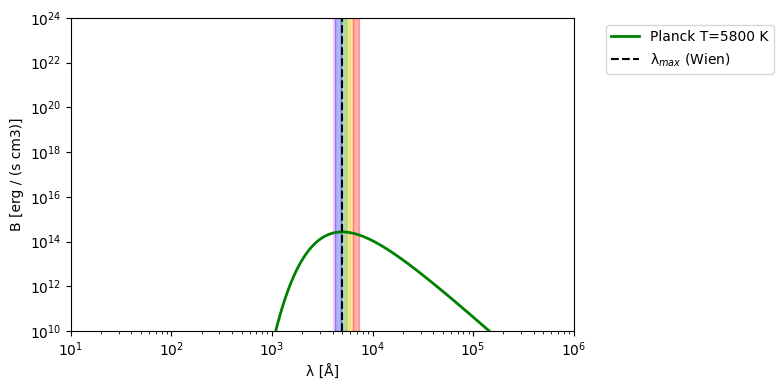

In [4]:
wav = np.arange(1E1, 1E6) # Angstroms — sin unidades, B_lambda las adjunta internamente

T = 5800 # K

B_sol = B_lambda(wav, T) # Calcula aqui para reutilizar valor y unidades

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(8, 4), dpi=100)

ax.axvspan(4000, 4250, alpha=0.3, color='violet') # banda visible
ax.axvspan(4250, 4900, alpha=0.3, color='blue')
ax.axvspan(4900, 5600, alpha=0.3, color='green')
ax.axvspan(5600, 5850, alpha=0.3, color='yellow')
ax.axvspan(5850, 6400, alpha=0.3, color='orange')
ax.axvspan(6400, 7400, alpha=0.3, color='red')
ax.set_ylim(1E10, 1E24)# con estas dos celdas puedo modificar y correr la curva
ax.set_xlim(1E1, 1E6)

ax.set_xlabel(r"λ [Å]")
ax.set_ylabel(r"B ​[{}]".format(B_sol.unit))
ax.set_xscale('log')
ax.set_yscale('log')

ax.plot(wav, B_sol.value, color="green", linewidth=2, linestyle='-', label=f'Planck T={T} K')

ax.axvline(lam_max_wien.value, color="black", linestyle='--', label=r'λ$_{max}$ (Wien)')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.tight_layout()
plt.show()

In [11]:
# Función auxiliar
def visible(a):
    a.axvspan ( 4000, 4250, alpha = 0.3, color = 'violet' ) 
    a.axvspan ( 4250, 4900, alpha = 0.3, color = 'blue' )
    a.axvspan ( 4900, 5600, alpha = 0.3, color = 'green' )
    a.axvspan ( 5600, 5850, alpha = 0.3, color = 'yellow' )
    a.axvspan ( 5850, 6400, alpha = 0.3, color = 'orange' )
    a.axvspan ( 6400, 7400, alpha = 0.3, color = 'red' )

**2.** La diferencia porcentual, estara dada por la diferencia de cada función respecto a la función de planck.

In [5]:
def error_pct(f_approx, f_exact):
    return np.abs((f_approx - f_exact) / f_exact) * 100

In [6]:
T = 5800
label = f'T={T} K (tipo G)'

In [7]:
lam_plot = np.logspace(2, 6, 2000)  # 100 AA a 1 mm
B  = B_lambda(lam_plot, T).value
W  = W_lambda(lam_plot, T).value
RJ = RJ_lambda(lam_plot, T).value


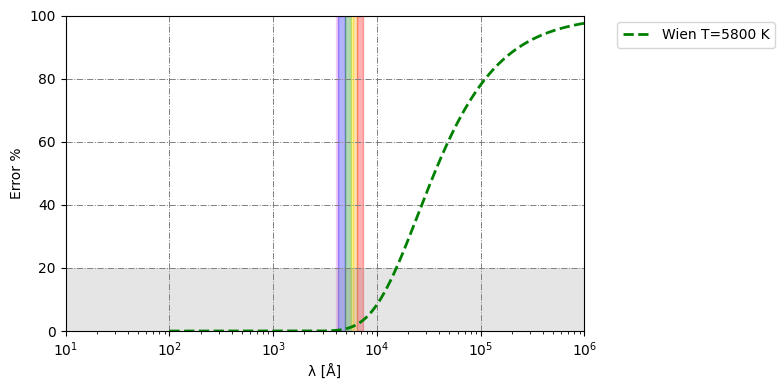

In [15]:
fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (8,4), dpi = 100 )
visible(ax) # banda vertical

ax.set_ylim ( 0., 100. )
ax.set_xlim(1E1, 1E6)

ax.set_xlabel(r"λ [Å]")
ax.set_ylabel('Error %')
ax.set_xscale ( 'log' )

ax.plot ( lam_plot, error_pct(W, B), color = "green", linewidth = 2, linestyle = '--', 
         label = 'Wien T=%i K' %T )

ax.grid ( color = 'gray', linestyle = '-.', linewidth = 0.7 )
ax.axhspan ( 0, 20, facecolor = "gray", alpha = 0.2 )

plt.legend ( bbox_to_anchor = (1.05, 1.0), loc = 'upper left' )
plt.tight_layout()
plt.show()

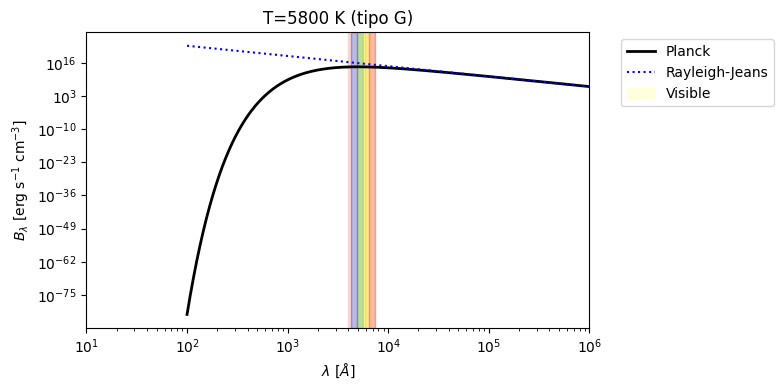

In [16]:
fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (8,4), dpi = 100 )
visible(ax) # banda vertical
ax.set_xlim(1E1, 1E6)

ax.loglog(lam_plot, B,  'k-',  lw=2,   label='Planck')
ax.loglog(lam_plot, RJ, 'b:',  lw=1.5, label='Rayleigh-Jeans')
ax.axvspan(4000, 7000, alpha=0.12, color='yellow', label='Visible')
ax.set_title(label)
ax.set_xlabel(r'$\lambda$ [$\AA$]')
ax.set_ylabel(r'$B_\lambda$ [erg s$^{-1}$ cm$^{-3}$]')
ax.legend(fontsize=9)

plt.legend ( bbox_to_anchor = (1.05, 1.0), loc = 'upper left' )
plt.tight_layout()
plt.show()

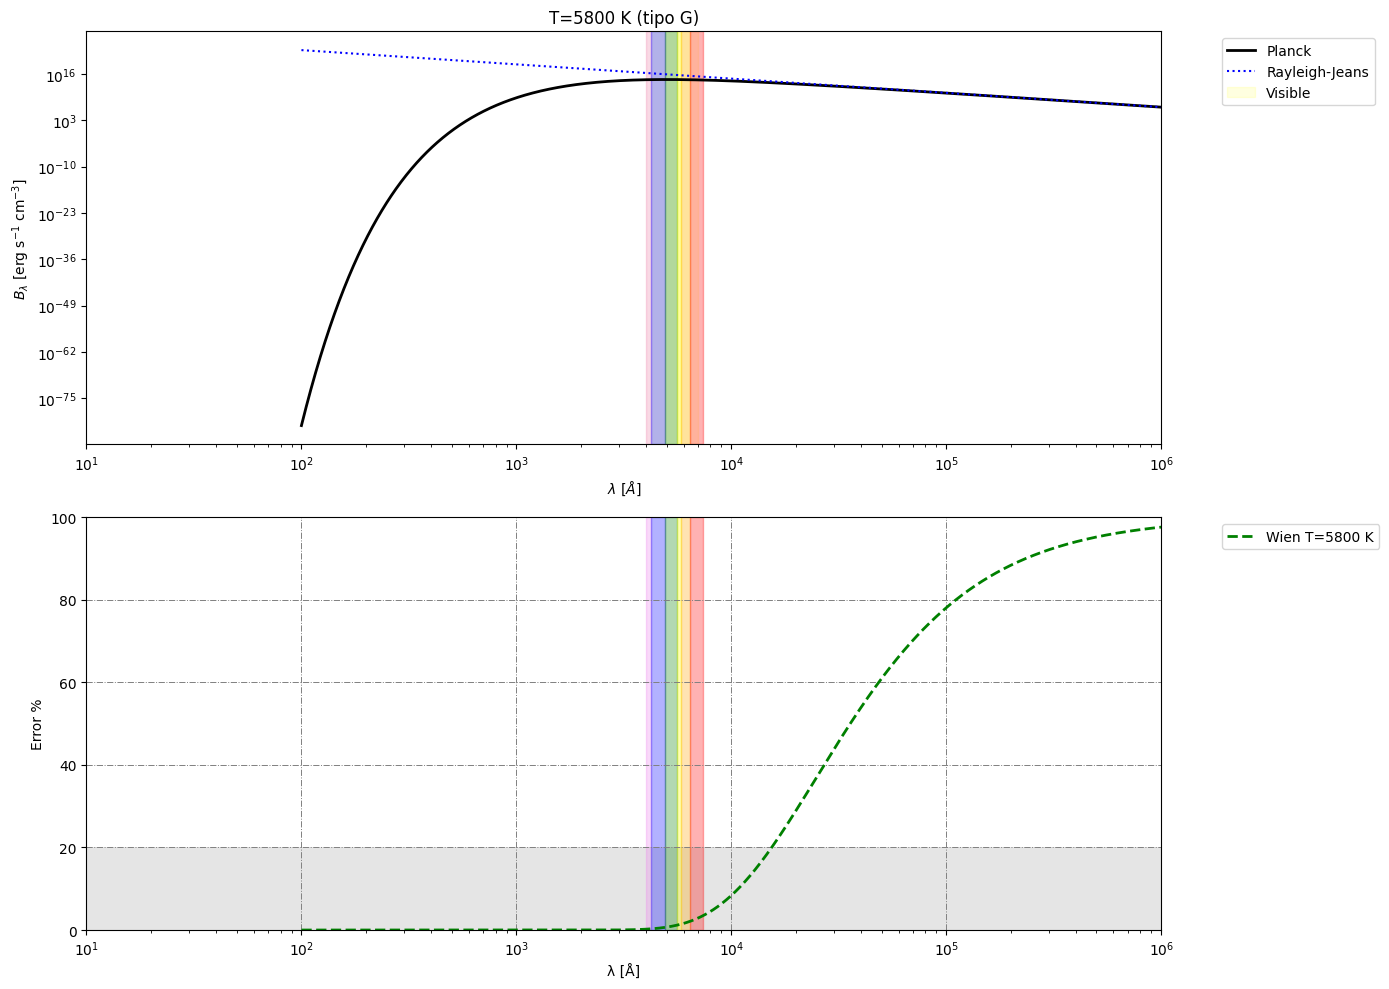

In [17]:
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(14, 10), dpi=100)

ax0.loglog(lam_plot, B,  'k-',  lw=2,   label='Planck')
ax0.loglog(lam_plot, RJ, 'b:',  lw=1.5, label='Rayleigh-Jeans')
ax0.axvspan(4000, 7000, alpha=0.12, color='yellow', label='Visible')
ax0.set_title(label)
ax0.set_xlabel(r'$\lambda$ [$\AA$]')
ax0.set_ylabel(r'$B_\lambda$ [erg s$^{-1}$ cm$^{-3}$]')
ax0.legend(fontsize=9)

ax1.set_ylim ( 0., 100. )
ax1.set_xlim(1E1, 1E6)

ax1.set_xlabel(r"λ [Å]")
ax1.set_ylabel('Error %')
ax1.set_xscale ( 'log' )

ax1.plot ( lam_plot, error_pct(W, B), color = "green", linewidth = 2, linestyle = '--', 
         label = 'Wien T=%i K' %T )

ax1.grid ( color = 'gray', linestyle = '-.', linewidth = 0.7 )
ax1.axhspan ( 0, 20, facecolor = "gray", alpha = 0.2 )

for ax in (ax0, ax1):
    ax.legend ( bbox_to_anchor = (1.05, 1.0), loc = 'upper left' )
    visible(ax) 
    ax.set_xlim(1E1, 1E6)

plt.tight_layout()
plt.show()

**3.** Cómo integrar una función

In [18]:
sigma = #editame
print (sigma)

SyntaxError: invalid syntax (298772535.py, line 1)

In [ ]:
from scipy.integrate import quad

# Redefino la funcion para no usar unidades y multiplico por pi por la integral
# en el angulo sólido
def bb(x):
    ''' Redefino la función para que tome la long. de onda en AA 
    y con el .value le saco las unidades para poder hacer la integral.
    Además, le agrego el pi para que represente el Flujo integrado.'''
    return np.pi * B(x * u.AA, Temp).value

Temp = 5800 * u.K

# Recuerde que para calcular la integral entre 4000 y 7000AA se puede usar 
#  la función interna de python _quad_.
int, err = quad ( bb, 4000, 7000 )

# Y para el Flujo total tiene la Ley de Boltzmann. En este caso, tener en cuenta
#  las unidades (lineales) del diferencial de long. de onda.